In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## Configuration


In [7]:
DATASET_FILE = "eye_dataset_v2.csv"

FEATURES = [
    "left_ear",
    "right_ear",
    "ear",
    "left_eye_width",
    "left_eye_height_1",
    "left_eye_height_2",
    "right_eye_width",
    "right_eye_height_1",
    "right_eye_height_2"
]

TARGET = "label"

df = pd.read_csv(DATASET_FILE)

print("\n================ DATASET INFO ================\n")

print("Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 samples:")
print(df.head())




================ DATASET INFO ================

Shape:
(1000, 10)

Columns:
['left_ear', 'right_ear', 'ear', 'left_eye_width', 'left_eye_height_1', 'left_eye_height_2', 'right_eye_width', 'right_eye_height_1', 'right_eye_height_2', 'label']

First 5 samples:
   left_ear  right_ear       ear  left_eye_width  left_eye_height_1  \
0  0.427398   0.432328  0.429863        0.039186           0.017069   
1  0.427019   0.435539  0.431279        0.039078           0.016954   
2  0.427494   0.447180  0.437337        0.039127           0.017017   
3  0.433946   0.444521  0.439234        0.039218           0.017375   
4  0.423431   0.440666  0.432049        0.039083           0.016941   

   left_eye_height_2  right_eye_width  right_eye_height_1  right_eye_height_2  \
0           0.016427         0.035552            0.014775            0.015965   
1           0.016420         0.035660            0.014906            0.016156   
2           0.016436         0.035825            0.015400            0

## MISSING VALUES

In [8]:

missing_columns = [
    column
    for column in FEATURES + [TARGET]
    if column not in df.columns
]

if missing_columns:

    raise ValueError(
        f"Missing columns: {missing_columns}"
    )


print("\n================ MISSING VALUES ================\n")

print(
    df[FEATURES + [TARGET]].isnull().sum()
)




================ MISSING VALUES ================

left_ear              0
right_ear             0
ear                   0
left_eye_width        0
left_eye_height_1     0
left_eye_height_2     0
right_eye_width       0
right_eye_height_1    0
right_eye_height_2    0
label                 0
dtype: int64


### Class distribution

In [9]:

print("\n================ CLASS DISTRIBUTION ================\n")

print(
    df[TARGET].value_counts()
)

print("\n================ FEATURE COUNT ================\n")

print(
    f"Number of features: {len(FEATURES)}"
)

print("\nFeatures:")

for i, feature in enumerate(FEATURES, 1):

    print(
        f"{i}. {feature}"
    )




================ CLASS DISTRIBUTION ================

label
OPEN      500
CLOSED    500
Name: count, dtype: int64

================ FEATURE COUNT ================

Number of features: 9

Features:
1. left_ear
2. right_ear
3. ear
4. left_eye_width
5. left_eye_height_1
6. left_eye_height_2
7. right_eye_width
8. right_eye_height_1
9. right_eye_height_2


### Statistical summary

In [10]:

print("\n================ STATISTICS ================\n")

print(
    df[FEATURES].describe()
)
print("\n================ FEATURE MEAN BY CLASS ================\n")

class_means = (
    df.groupby(TARGET)[FEATURES]
    .mean()
)

print(
    class_means
)




================ STATISTICS ================

          left_ear    right_ear          ear  left_eye_width  \
count  1000.000000  1000.000000  1000.000000     1000.000000   
mean      0.292335     0.305452     0.298893        0.032483   
std       0.143089     0.127559     0.133649        0.004578   
min       0.054400     0.048740     0.066892        0.019822   
25%       0.140102     0.172797     0.152725        0.029676   
50%       0.342990     0.354160     0.342888        0.033287   
75%       0.429322     0.425416     0.429337        0.036284   
max       0.487539     0.520614     0.488314        0.040802   

       left_eye_height_1  left_eye_height_2  right_eye_width  \
count        1000.000000        1000.000000      1000.000000   
mean            0.010246           0.009663         0.031396   
std             0.005681           0.005536         0.004148   
min             0.001509           0.001277         0.018107   
25%             0.004137           0.003757         0.02

In [11]:

print("\n================ FEATURE STD BY CLASS ================\n")

class_std = (
    df.groupby(TARGET)[FEATURES]
    .std()
)

print(
    class_std
)

print("\n================ FEATURE MIN BY CLASS ================\n")

class_min = (
    df.groupby(TARGET)[FEATURES]
    .min()
)

print(
    class_min
)

print("\n================ FEATURE MAX BY CLASS ================\n")

class_max = (
    df.groupby(TARGET)[FEATURES]
    .max()
)

print(
    class_max
)




================ FEATURE STD BY CLASS ================

        left_ear  right_ear       ear  left_eye_width  left_eye_height_1  \
label                                                                      
CLOSED  0.072134   0.074194  0.068648        0.003891           0.002473   
OPEN    0.038386   0.042011  0.037540        0.002469           0.001840   

        left_eye_height_2  right_eye_width  right_eye_height_1  \
label                                                            
CLOSED           0.002412         0.003461            0.002187   
OPEN             0.001881         0.003274            0.002104   

        right_eye_height_2  
label                       
CLOSED            0.002350  
OPEN              0.002021  

================ FEATURE MIN BY CLASS ================

        left_ear  right_ear       ear  left_eye_width  left_eye_height_1  \
label                                                                      
CLOSED  0.054400   0.048740  0.066892        0.0

### EAR distribution

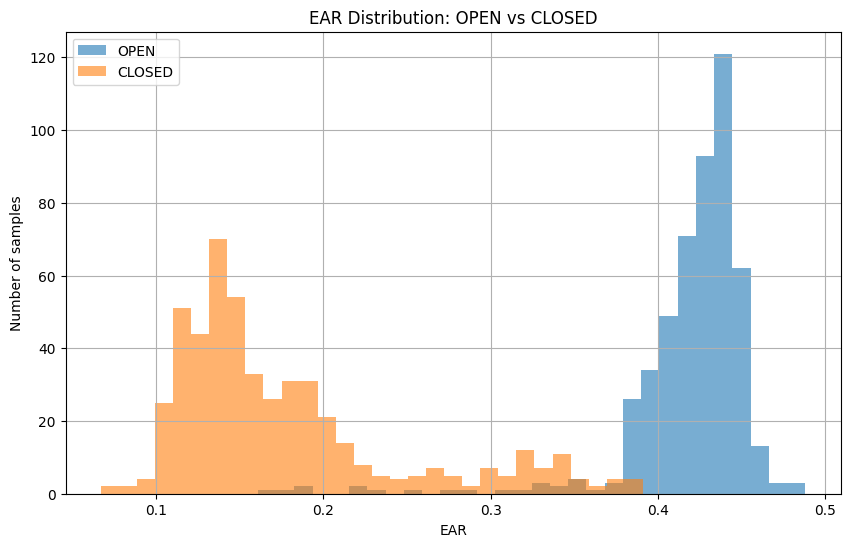

In [12]:

plt.figure(
    figsize=(10, 6)
)

for label in df[TARGET].unique():

    subset = df[
        df[TARGET] == label
    ]

    plt.hist(
        subset["ear"],
        bins=30,
        alpha=0.6,
        label=label
    )


plt.xlabel("EAR")
plt.ylabel("Number of samples")

plt.title(
    "EAR Distribution: OPEN vs CLOSED"
)

plt.legend()
plt.grid(True)

plt.show()



### EAR Boxplot

<Figure size 800x600 with 0 Axes>

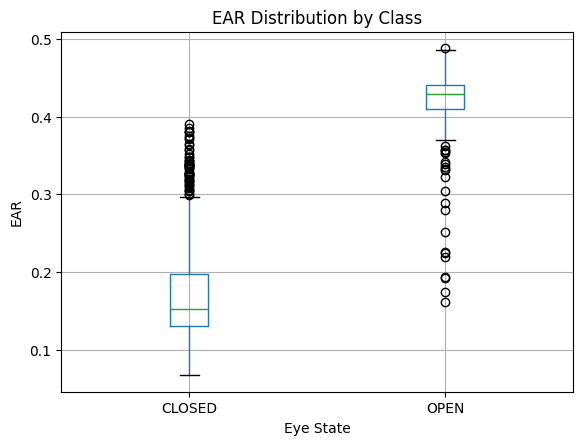

In [13]:

plt.figure(
    figsize=(8, 6)
)

df.boxplot(
    column="ear",
    by=TARGET
)

plt.xlabel("Eye State")
plt.ylabel("EAR")

plt.title(
    "EAR Distribution by Class"
)

plt.suptitle("")

plt.show()



### Feature correlation

In [14]:


print(
    "\n================ FEATURE CORRELATION ================\n"
)

correlation_matrix = (
    df[FEATURES].corr()
)

print(
    correlation_matrix
)



# Correlation with EAR


print(
    "\n================ CORRELATION WITH EAR ================\n"
)

ear_correlation = (
    correlation_matrix["ear"]
    .sort_values(
        ascending=False
    )
)

print(
    ear_correlation
)



# Correlation with numerical label


print(
    "\n================ FEATURE CLASS SEPARATION ================\n"
)

# Convert class to binary value
# CLOSED = 0
# OPEN   = 1

df["label_numeric"] = (
    df[TARGET]
    .map({
        "CLOSED": 0,
        "OPEN": 1
    })
)

class_correlation = (
    df[FEATURES + ["label_numeric"]]
    .corr()["label_numeric"]
    .drop("label_numeric")
    .sort_values(
        ascending=False
    )
)

print(
    class_correlation
)



print(
    "\n================ ANALYSIS COMPLETE ================\n"
)

print(
    f"Dataset samples : {len(df)}"
)

print(
    f"Features        : {len(FEATURES)}"
)

print(
    "Classes:"
)

print(
    df[TARGET].value_counts()
)


================ FEATURE CORRELATION ================

                    left_ear  right_ear       ear  left_eye_width  \
left_ear            1.000000   0.950638  0.988975        0.700568   
right_ear           0.950638   1.000000  0.986107        0.735758   
ear                 0.988975   0.986107  1.000000        0.726141   
left_eye_width      0.700568   0.735758  0.726141        1.000000   
left_eye_height_1   0.987080   0.951449  0.982446        0.786686   
left_eye_height_2   0.986677   0.949634  0.981364        0.786037   
right_eye_width     0.520647   0.528246  0.530798        0.765798   
right_eye_height_1  0.931870   0.967317  0.960463        0.789821   
right_eye_height_2  0.930818   0.970160  0.961257        0.798032   

                    left_eye_height_1  left_eye_height_2  right_eye_width  \
left_ear                     0.987080           0.986677         0.520647   
right_ear                    0.951449           0.949634         0.528246   
ear                   

# Visualisation


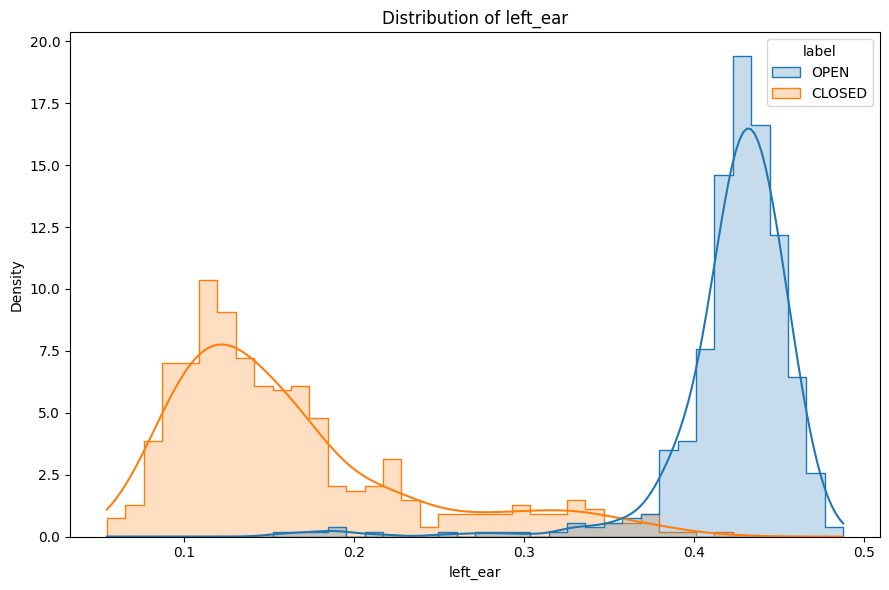

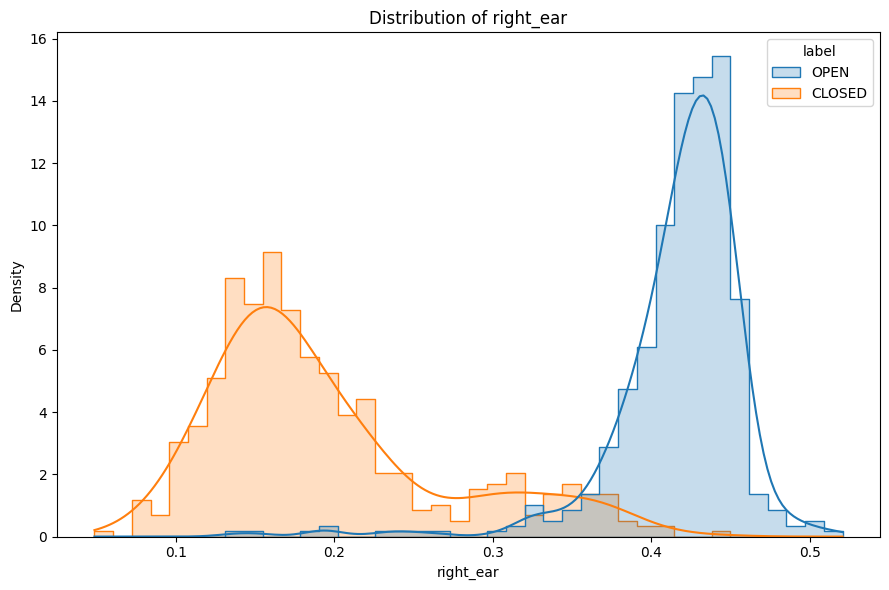

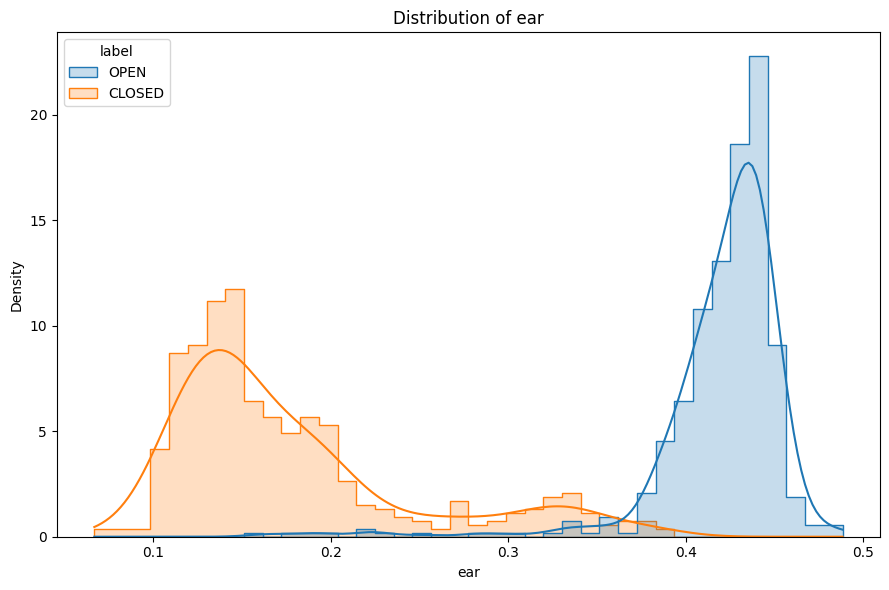

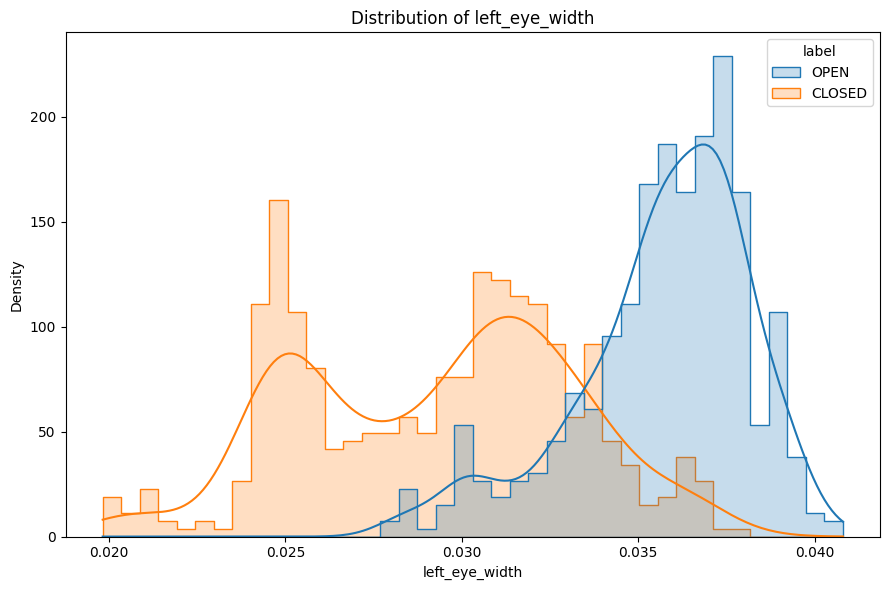

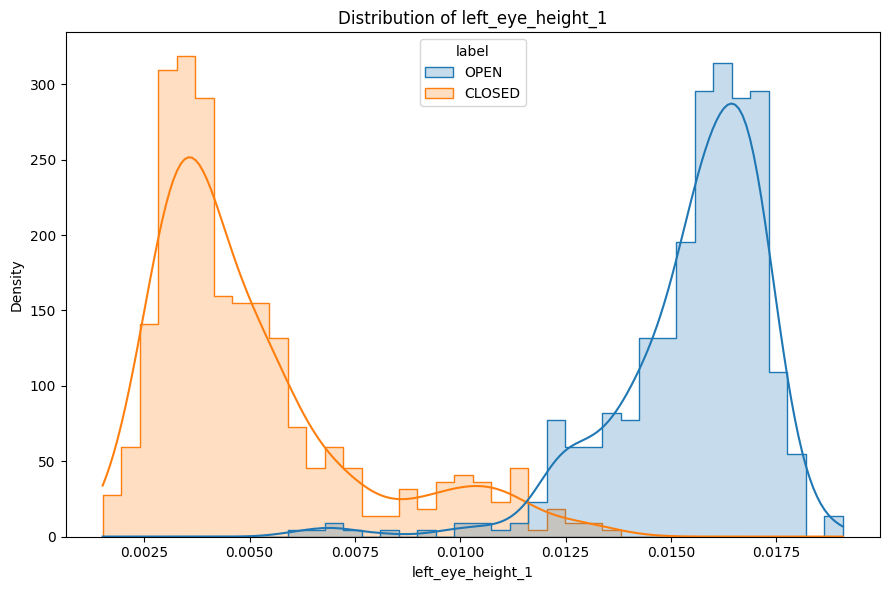

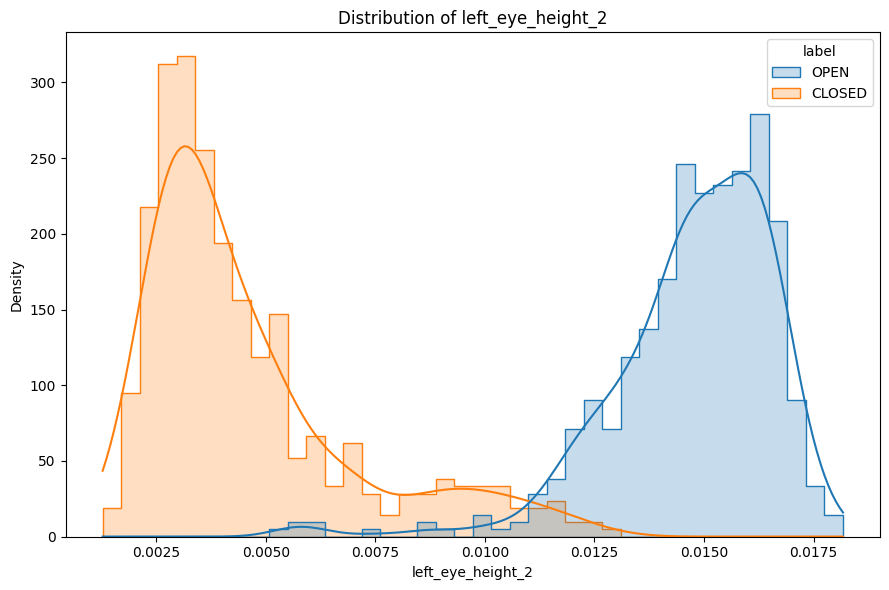

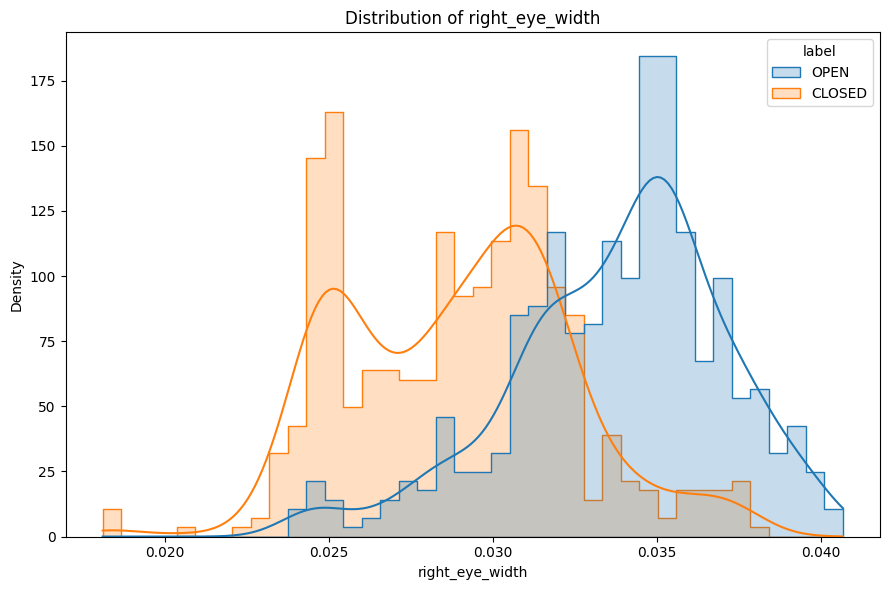

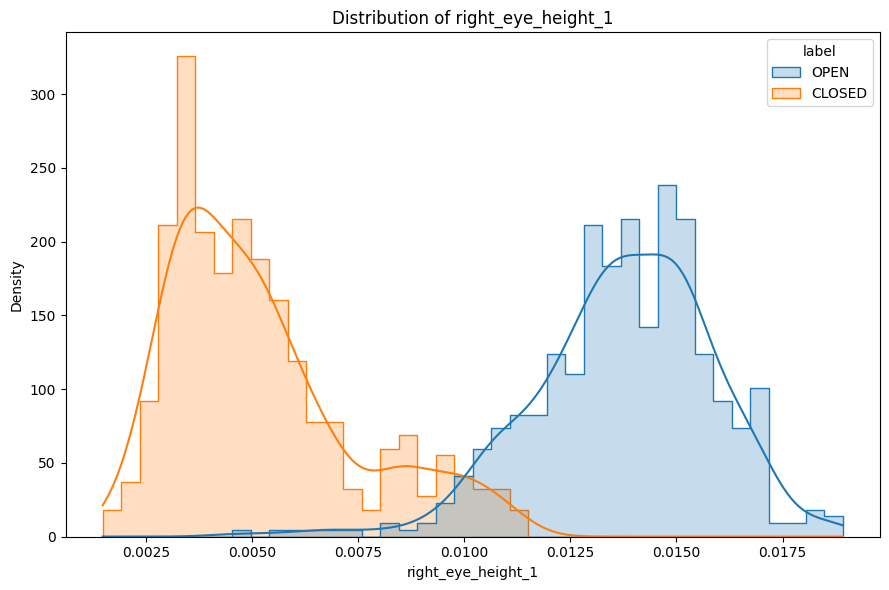

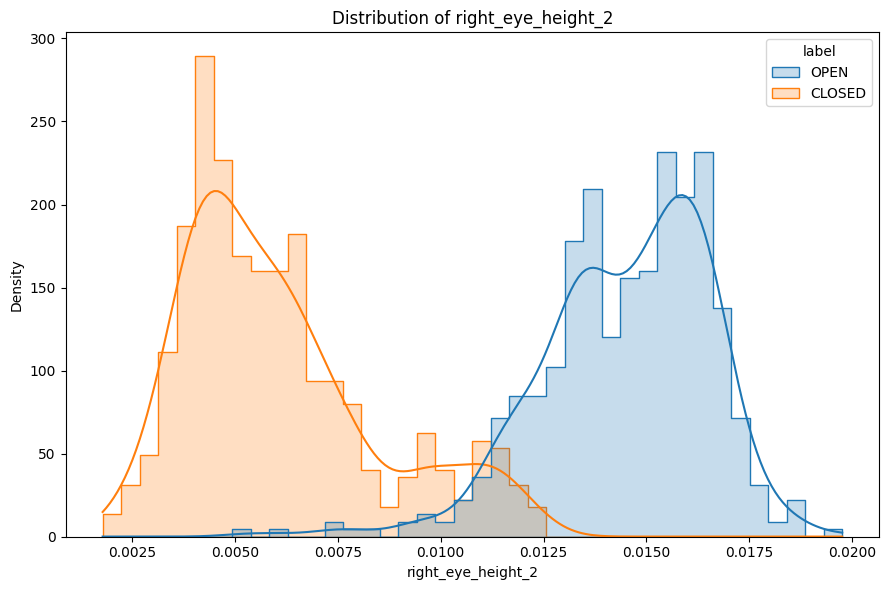

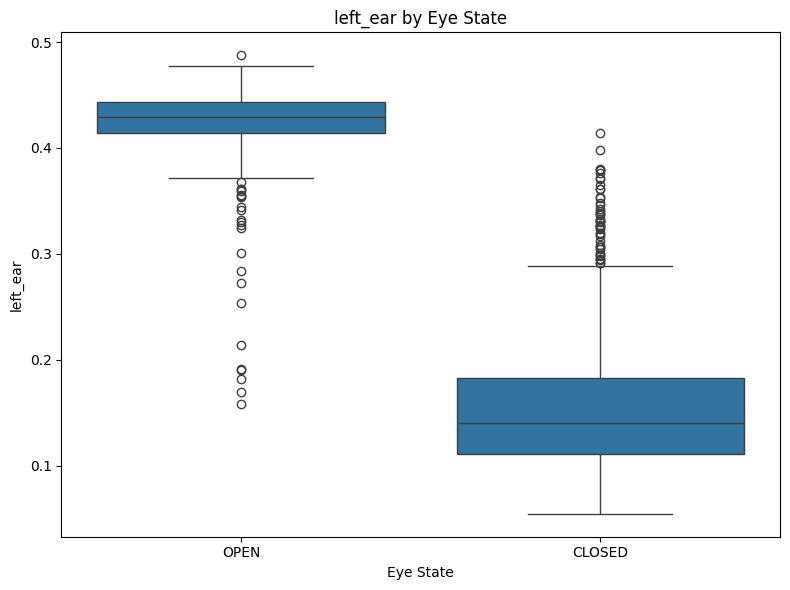

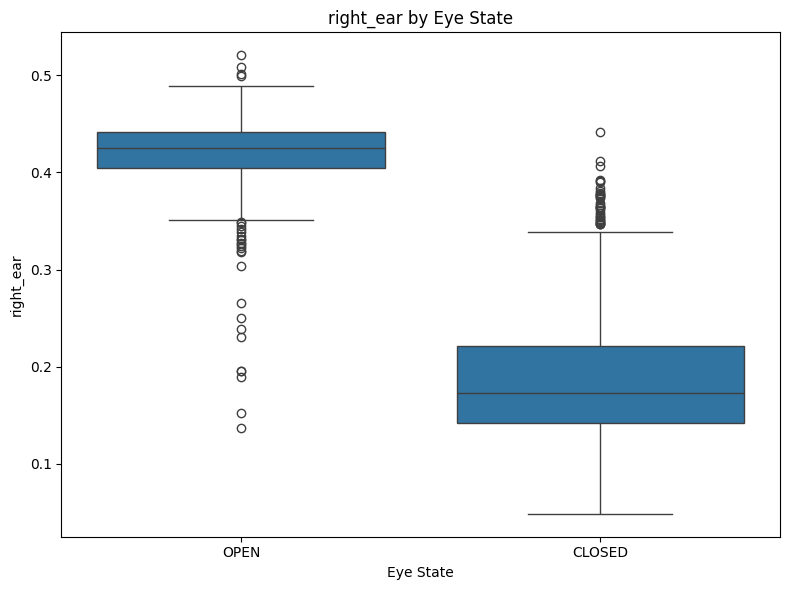

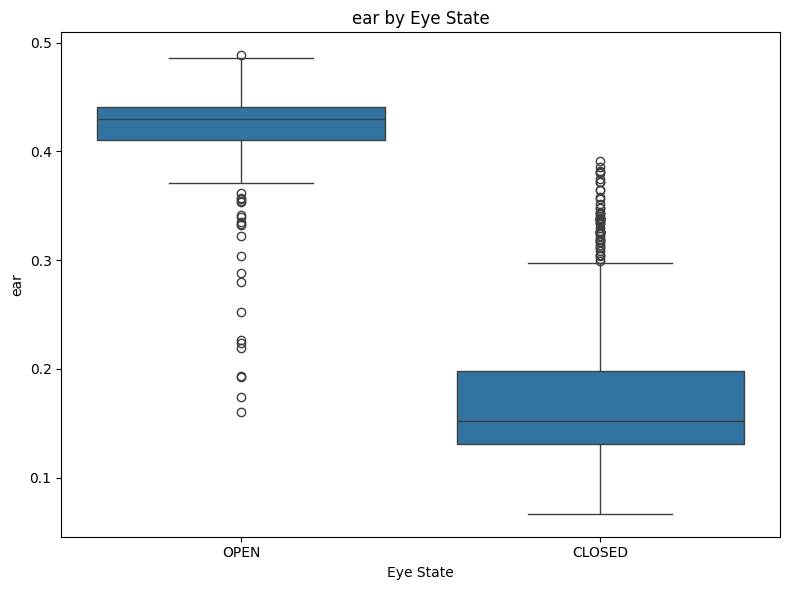

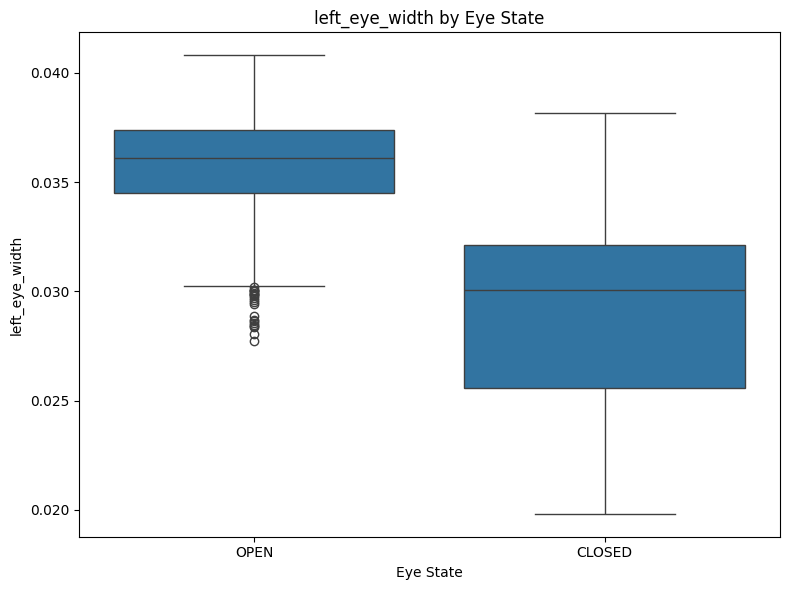

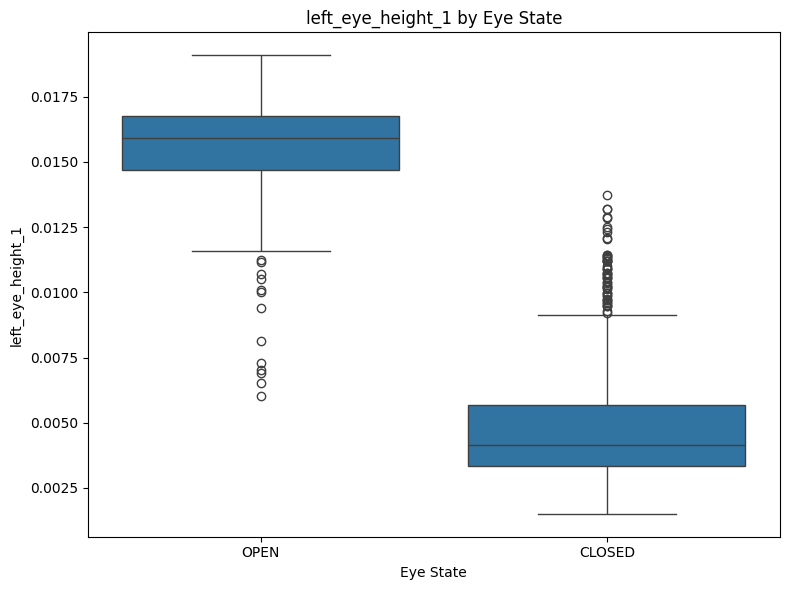

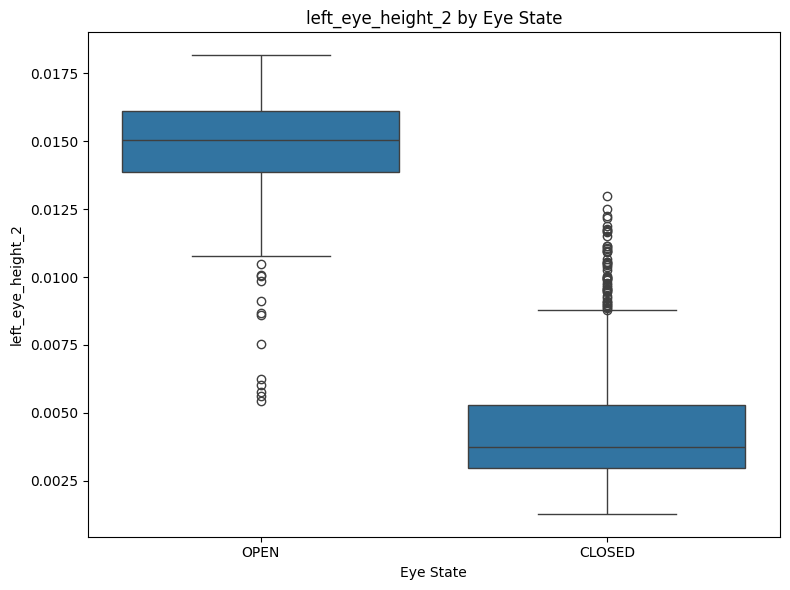

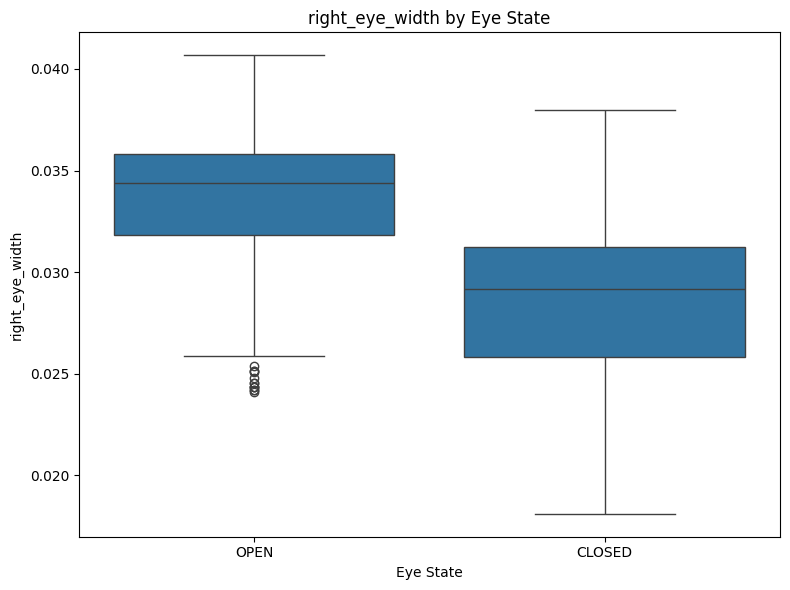

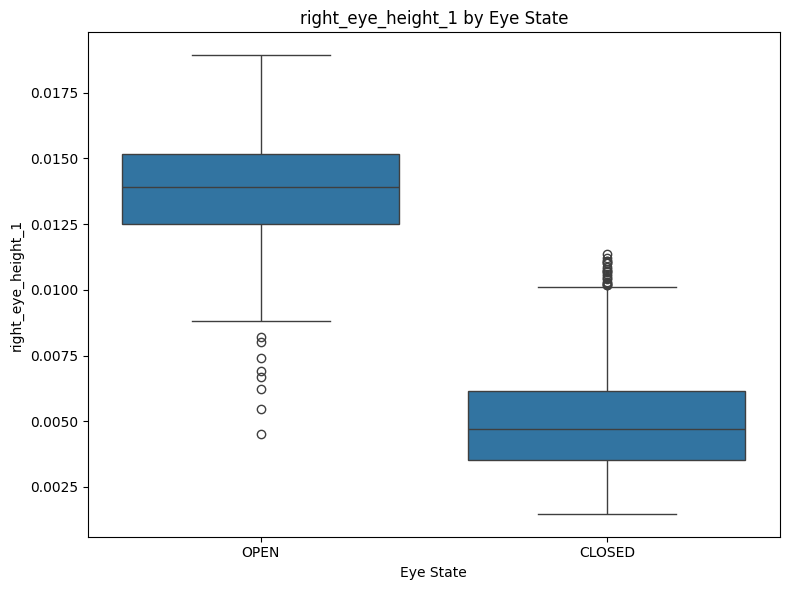

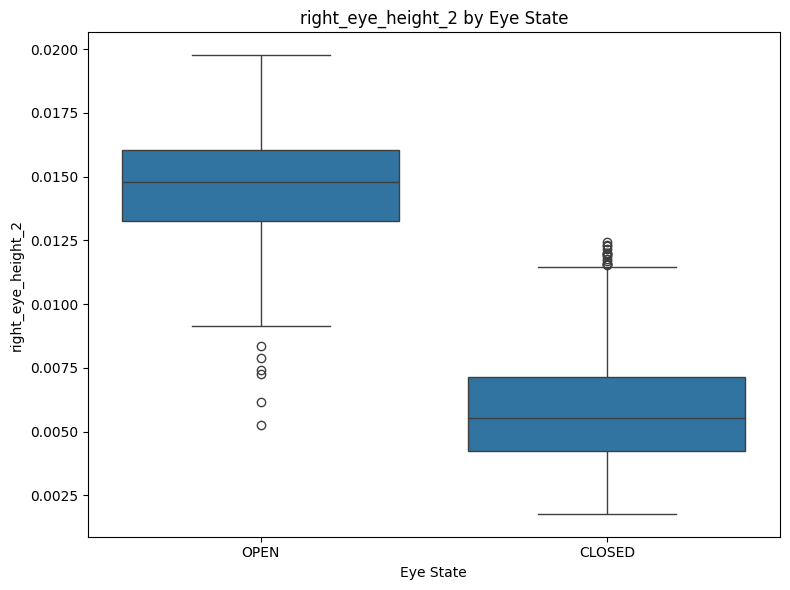


CORRELATION MATRIX
                    left_ear  right_ear     ear  left_eye_width  \
left_ear              1.0000     0.9506  0.9890          0.7006   
right_ear             0.9506     1.0000  0.9861          0.7358   
ear                   0.9890     0.9861  1.0000          0.7261   
left_eye_width        0.7006     0.7358  0.7261          1.0000   
left_eye_height_1     0.9871     0.9514  0.9824          0.7867   
left_eye_height_2     0.9867     0.9496  0.9814          0.7860   
right_eye_width       0.5206     0.5282  0.5308          0.7658   
right_eye_height_1    0.9319     0.9673  0.9605          0.7898   
right_eye_height_2    0.9308     0.9702  0.9613          0.7980   

                    left_eye_height_1  left_eye_height_2  right_eye_width  \
left_ear                       0.9871             0.9867           0.5206   
right_ear                      0.9514             0.9496           0.5282   
ear                            0.9824             0.9814           0.5308   
l

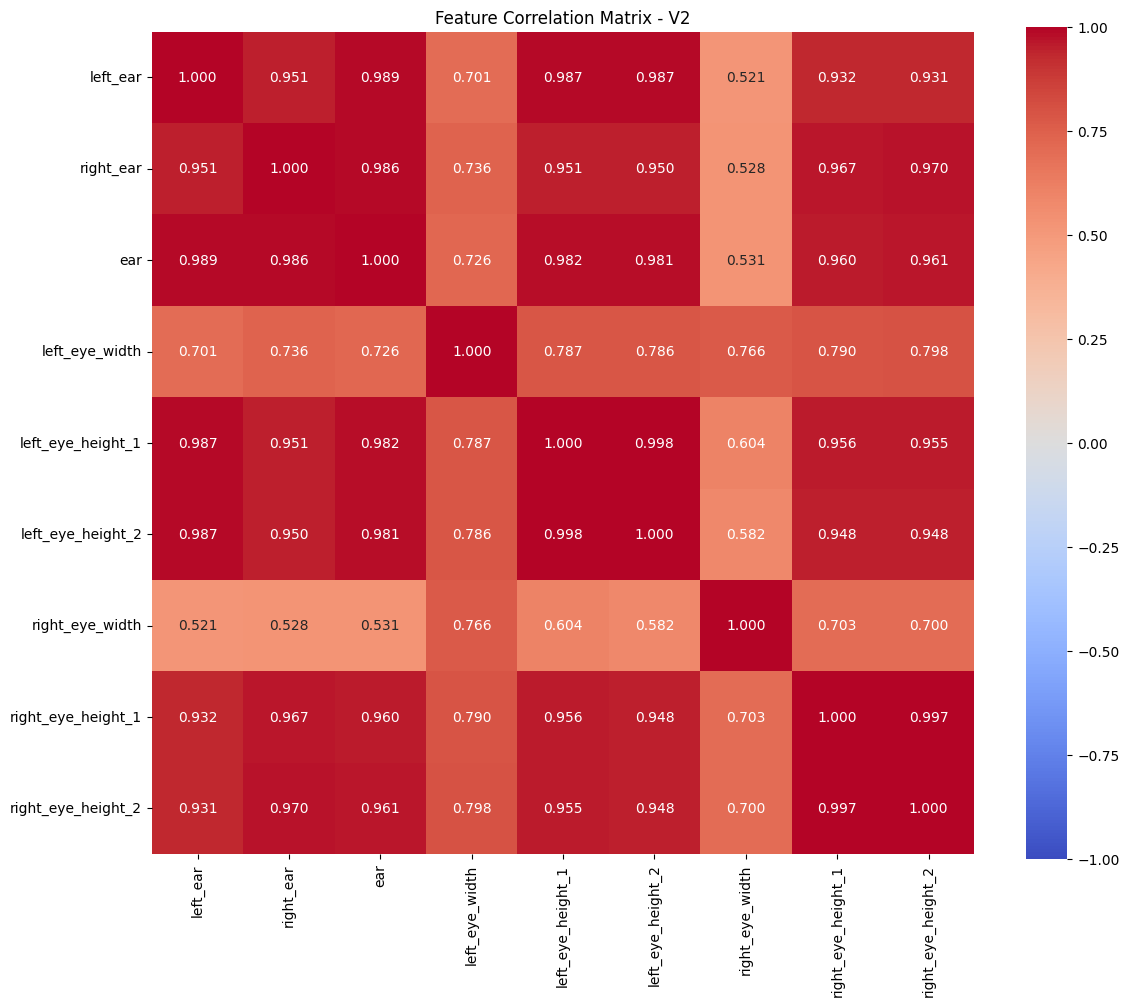

In [17]:

for feature in FEATURES:

    plt.figure(
        figsize=(9, 6)
    )

    sns.histplot(
        data=df,
        x=feature,
        hue=TARGET,
        kde=True,
        bins=40,
        element="step",
        stat="density",
        common_norm=False
    )

    plt.title(
        f"Distribution of {feature}"
    )

    plt.xlabel(
        feature
    )

    plt.ylabel(
        "Density"
    )

    plt.tight_layout()

    plt.show()


# Boxplots

for feature in FEATURES:

    plt.figure(
        figsize=(8, 6)
    )

    sns.boxplot(
        data=df,
        x=TARGET,
        y=feature
    )

    plt.title(
        f"{feature} by Eye State"
    )

    plt.xlabel(
        "Eye State"
    )

    plt.ylabel(
        feature
    )

    plt.tight_layout()

    plt.show()


# Correlation Matrix


print()
print("=" * 70)
print("CORRELATION MATRIX")
print("=" * 70)

correlation_matrix = (
    df[FEATURES]
    .corr()
)

print(
    correlation_matrix
    .round(4)
)


# Correlation Heatmap


plt.figure(
    figsize=(12, 10)
)

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True
)

plt.title(
    "Feature Correlation Matrix - V2"
)

plt.tight_layout()

plt.show()




In [18]:

# Class separation

print()
print("=" * 70)
print("CLASS MEAN COMPARISON")
print("=" * 70)

class_means = (
    df.groupby(TARGET)[FEATURES]
    .mean()
)

print(
    class_means
    .round(6)
)



# OPEN / CLOSED Mean Difference


if "OPEN" in df[TARGET].values and "CLOSED" in df[TARGET].values:

    print()
    print("=" * 70)
    print("OPEN vs CLOSED MEAN DIFFERENCE")
    print("=" * 70)

    open_mean = (
        df[df[TARGET] == "OPEN"][FEATURES]
        .mean()
    )

    closed_mean = (
        df[df[TARGET] == "CLOSED"][FEATURES]
        .mean()
    )

    comparison = pd.DataFrame({

        "OPEN_mean":
            open_mean,

        "CLOSED_mean":
            closed_mean,

        "ABS_difference":
            abs(open_mean - closed_mean)

    })

    print(
        comparison
        .sort_values(
            "ABS_difference",
            ascending=False
        )
        .round(6)
    )



print()
print("=" * 70)
print("FEATURE ANALYSIS COMPLETE")
print("=" * 70)

print()
print(f"Dataset samples : {len(df)}")
print(f"Features        : {len(FEATURES)}")

print()
print("Features analyzed:")

for i, feature in enumerate(FEATURES, 1):

    print(
        f"{i}. {feature}"
    )

print()


CLASS MEAN COMPARISON
        left_ear  right_ear       ear  left_eye_width  left_eye_height_1  \
label                                                                      
CLOSED  0.161483   0.193080  0.177281        0.029268           0.005002   
OPEN    0.423187   0.417823  0.420505        0.035698           0.015490   

        left_eye_height_2  right_eye_width  right_eye_height_1  \
label                                                            
CLOSED           0.004569         0.028975            0.005179   
OPEN             0.014756         0.033817            0.013753   

        right_eye_height_2  
label                       
CLOSED            0.006029  
OPEN              0.014516  

OPEN vs CLOSED MEAN DIFFERENCE
                    OPEN_mean  CLOSED_mean  ABS_difference
left_ear             0.423187     0.161483        0.261705
ear                  0.420505     0.177281        0.243224
right_ear            0.417823     0.193080        0.224743
left_eye_height_1    0.